# Seasonal Performance Study of Indian Farms
### An independent data-analytics investigation into how season shapes agricultural outcomes

**Dataset:** `seasonal_agriculture_performance_dataset.csv` — 4,000 farm-level records across 8 states, 8 crops and 3 growing seasons (Kharif, Rabi, Zaid)

**Author's note:** This notebook is an original analysis built for the AICTE/VOIS Major Project brief on Seasonal Agriculture Performance. It follows my own structure and reasoning rather than reproducing any shared template line-by-line.

## 1. Why This Study Matters

Farming outcomes in India don't stay constant through the year — the same land, under different seasonal conditions, can produce very different results. Rainfall timing, temperature swings, pest pressure and even market prices all move with the calendar.

The brief for this project asks a fairly open question: **what does seasonality actually do to farm performance, and can we find evidence-backed patterns in it?**

Rather than analyzing the dataset column-by-column with no direction, this notebook works toward a small set of guiding questions:

1. Does the season a crop is grown in meaningfully change its yield and profitability?
2. What resource and environmental factors move together with performance?
3. Are seasonal patterns consistent across states, or do they vary regionally?
4. Where is the financial and agronomic risk concentrated?

Everything below builds toward answering those four questions with evidence from the data — not assumptions.

In [1]:
# --- Environment setup ---
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="darkgrid", palette="Set2")
plt.rcParams["figure.dpi"] = 100
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda v: f"{v:,.2f}")

print("Libraries ready.")

Libraries ready.


In [2]:
# --- Bring in the dataset ---
# Works directly in Google Colab: if the file isn't already sitting next to
# this notebook, it opens the upload picker so you can select
# "seasonal_agriculture_performance_dataset.csv" yourself.

import os

DATA_FILE = "seasonal_agriculture_performance_dataset.csv"

if not os.path.exists(DATA_FILE):
    try:
        from google.colab import files
        print("Upload seasonal_agriculture_performance_dataset.csv when prompted:")
        picked = files.upload()
        DATA_FILE = list(picked.keys())[0]
    except ImportError:
        DATA_FILE = "/content/seasonal_agriculture_performance_dataset.csv"

agri = pd.read_csv(DATA_FILE)
print(f"Loaded {agri.shape[0]:,} rows and {agri.shape[1]} columns.")

Loaded 4,000 rows and 28 columns.


## 2. Getting Acquainted With the Data

In [3]:
agri.head()

,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,Irrigation_Method,Fertilizer_kg_ha,Pesticide_Litre_ha,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
0,SF10001,Andhra Pradesh,Rajkot,Wheat,Kharif,0.53,486.40,24.30,69.10,5.80,7.14,32.80,75.80,61.30,91.00,Drip,242.70,4.33,0.76,2.46,1.30,23700,42662,30810,-11852,237,5.49,55.30
1,SF10002,Maharashtra,Nalgonda,Maize,Kharif,6.53,855.40,25.70,78.40,5.10,5.20,32.00,82.10,35.40,121.80,Flood,271.40,6.86,0.94,0.30,1.96,20613,492351,40401,-451950,4953,0.40,49.90
2,SF10003,Telangana,Warangal,Pulses,Rabi,4.86,455.60,23.90,56.40,10.30,5.82,8.10,118.50,51.50,117.90,Drip,162.60,6.08,0.98,0.52,2.53,75283,315210,190466,-124744,1275,1.98,33.70
3,SF10004,Telangana,Indore,Rice,Kharif,4.50,753.20,29.70,65.20,6.30,5.98,23.70,138.60,55.60,115.50,Rainfed,182.20,6.39,0.74,1.84,8.28,24244,296444,200740,-95704,3834,2.16,50.60
4,SF10005,Karnataka,Ludhiana,Maize,Zaid,4.21,101.60,34.10,55.20,6.50,6.90,29.30,124.10,69.00,121.40,Flood,244.90,7.61,0.90,2.21,9.30,20818,337959,193607,-144352,3287,2.83,32.30


In [4]:
agri.sample(6, random_state=7)

,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,Irrigation_Method,Fertilizer_kg_ha,Pesticide_Litre_ha,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
2060,SF12061,Gujarat,Erode,Wheat,Kharif,8.57,"1,147.30",31.90,72.50,5.20,7.94,29.10,142.00,29.30,135.40,Sprinkler,58.30,1.28,0.91,0.33,2.83,24959,469713,70634,-399079,3713,0.76,73.90
933,SF10934,Telangana,Krishna,Wheat,Kharif,0.72,792.60,30.90,83.30,7.80,6.88,31.20,150.20,39.40,50.10,Rainfed,244.30,2.71,0.71,2.60,1.87,26051,44873,48715,3842,225,8.31,71.90
378,SF10379,Karnataka,Warangal,Maize,Kharif,10.20,"1,003.00",29.80,85.00,6.20,6.52,36.70,119.00,58.30,69.10,Flood,343.20,4.15,0.78,4.10,41.82,22998,779375,961776,182401,8738,4.79,61.40
2754,SF12755,Andhra Pradesh,Warangal,Pulses,Rabi,11.08,510.20,25.80,54.70,6.60,6.01,29.80,107.40,55.60,136.00,Flood,137.00,8.08,0.66,0.78,8.64,69418,736899,599772,-137127,4918,1.76,29.50
596,SF10597,Andhra Pradesh,Krishna,Rice,Zaid,13.96,89.90,28.50,43.40,9.50,6.83,15.90,79.30,35.50,142.10,Rainfed,222.50,4.67,0.91,1.81,25.27,24312,877099,614364,-262735,9860,2.56,37.90
3496,SF13497,Andhra Pradesh,Warangal,Groundnut,Rabi,2.74,202.20,25.70,58.70,7.80,7.35,25.60,72.70,38.70,127.20,Flood,240.20,6.96,0.74,0.89,2.44,58532,181209,142818,-38391,1830,1.33,29.40


In [5]:
print("Rows x Columns:", agri.shape)
agri.info()

Rows x Columns: (4000, 28)
<class 'pandas.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 28 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Farm_ID                        4000 non-null   str    
 1   State                          4000 non-null   str    
 2   District                       4000 non-null   str    
 3   Crop                           4000 non-null   str    
 4   Season                         4000 non-null   str    
 5   Farm_Area_Hectares             4000 non-null   float64
 6   Rainfall_mm                    3952 non-null   float64
 7   Avg_Temperature_C              4000 non-null   float64
 8   Humidity_pct                   4000 non-null   float64
 9   Sunlight_Hours_Day             4000 non-null   float64
 10  Soil_pH                        4000 non-null   float64
 11  Soil_Moisture_pct              3960 non-null   float64
 12  Nitrogen_kg_ha                 4

In [6]:
agri.describe().T

,count,mean,std,min,25%,50%,75%,max
Farm_Area_Hectares,"4,000.00",7.89,4.22,0.50,4.26,7.89,11.65,15.00
Rainfall_mm,"3,952.00",601.15,288.93,80.00,370.20,582.00,834.95,"1,395.20"
Avg_Temperature_C,"4,000.00",26.82,3.82,16.20,23.90,26.90,29.60,39.70
Humidity_pct,"4,000.00",63.21,11.96,25.00,54.77,63.00,71.90,95.00
Sunlight_Hours_Day,"4,000.00",7.32,1.12,3.50,6.60,7.30,8.10,11.00
Soil_pH,"4,000.00",6.70,0.64,5.20,6.26,6.69,7.14,8.40
Soil_Moisture_pct,"3,960.00",26.51,6.71,8.00,21.70,26.40,31.30,47.00
Nitrogen_kg_ha,"4,000.00",120.25,31.22,40.00,98.50,120.10,141.22,220.00
Phosphorus_kg_ha,"4,000.00",57.78,17.02,15.00,46.20,57.50,69.40,120.00
Potassium_kg_ha,"4,000.00",104.76,27.74,30.00,86.20,105.10,123.60,200.00


In [7]:
agri.describe(include="object").T

/tmp/ipykernel_477/3327923974.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  agri.describe(include="object").T


,count,unique,top,freq
Farm_ID,4000,4000,SF10001,1
State,4000,8,Andhra Pradesh,529
District,4000,10,Ludhiana,427
Crop,4000,8,Rice,690
Season,4000,3,Kharif,1779
Irrigation_Method,4000,4,Flood,1310


## 3. Cleaning Pass

Before drawing any conclusions, the dataset needs a quick health check: are there duplicate rows, missing values, or obviously broken entries?

In [8]:
null_counts = agri.isnull().sum()
null_pct = (null_counts / len(agri) * 100).round(2)
quality_check = pd.DataFrame({"Missing_Values": null_counts, "Missing_Pct": null_pct})
quality_check = quality_check[quality_check.Missing_Values > 0].sort_values("Missing_Values", ascending=False)
quality_check

,Missing_Values,Missing_Pct
Rainfall_mm,48,1.20
Soil_Moisture_pct,40,1.00
Yield_Tonnes_Ha,32,0.80


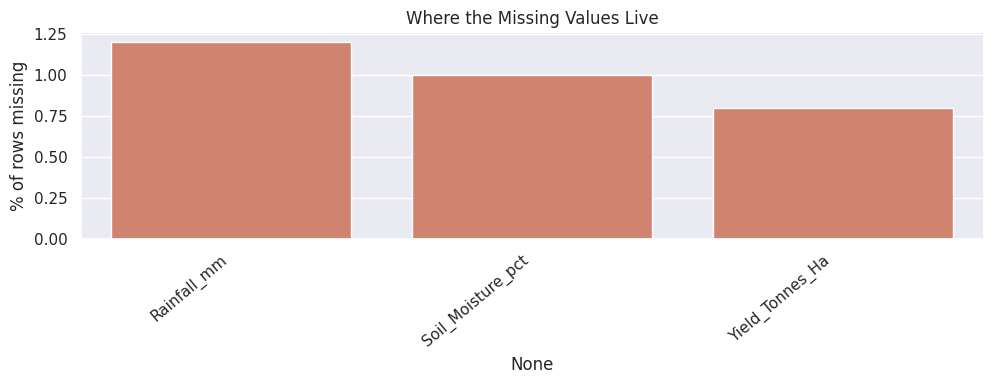

In [9]:
if len(quality_check):
    fig, ax = plt.subplots(figsize=(10, 4))
    sns.barplot(x=quality_check.index, y=quality_check["Missing_Pct"], ax=ax, color="#e07a5f")
    ax.set_title("Where the Missing Values Live")
    ax.set_ylabel("% of rows missing")
    plt.xticks(rotation=40, ha="right")
    plt.tight_layout()
    plt.show()
else:
    print("No missing values to plot.")

In [10]:
dupes = agri.duplicated().sum()
print(f"Duplicate rows found: {dupes}")
agri = agri.drop_duplicates().reset_index(drop=True)
print(f"Row count after de-duplication: {len(agri):,}")

Duplicate rows found: 0
Row count after de-duplication: 4,000


In [11]:
# Fill any numeric gaps with the column median (robust to outliers)
num_cols = agri.select_dtypes(include=np.number).columns

for col in num_cols:
    gaps = agri[col].isnull().sum()
    if gaps:
        agri[col] = agri[col].fillna(agri[col].median())
        print(f"Filled {gaps} gaps in '{col}' with the median.")

print("\nRemaining missing values overall:", agri.isnull().sum().sum())

Filled 48 gaps in 'Rainfall_mm' with the median.
Filled 40 gaps in 'Soil_Moisture_pct' with the median.
Filled 32 gaps in 'Yield_Tonnes_Ha' with the median.

Remaining missing values overall: 0


## 4. Sorting the Variables

In [12]:
numeric_features = agri.select_dtypes(include=np.number).columns.tolist()
categorical_features = agri.select_dtypes(include="object").columns.tolist()

print(f"Numeric ({len(numeric_features)}):\n{numeric_features}\n")
print(f"Categorical ({len(categorical_features)}):\n{categorical_features}")

Numeric (22):
['Farm_Area_Hectares', 'Rainfall_mm', 'Avg_Temperature_C', 'Humidity_pct', 'Sunlight_Hours_Day', 'Soil_pH', 'Soil_Moisture_pct', 'Nitrogen_kg_ha', 'Phosphorus_kg_ha', 'Potassium_kg_ha', 'Fertilizer_kg_ha', 'Pesticide_Litre_ha', 'Seed_Quality_Score', 'Yield_Tonnes_Ha', 'Production_Tonnes', 'Market_Price_INR_Tonne', 'Total_Cost_INR', 'Revenue_INR', 'Profit_INR', 'Water_Used_m3', 'Water_Efficiency_t_per_1000m3', 'Disease_Pest_Risk_pct']

Categorical (6):
['Farm_ID', 'State', 'District', 'Crop', 'Season', 'Irrigation_Method']


/tmp/ipykernel_477/3406582339.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features = agri.select_dtypes(include="object").columns.tolist()


In [13]:
for col in categorical_features:
    print(f"{col}: {agri[col].nunique()} unique -> {sorted(agri[col].unique())}")

Farm_ID: 4000 unique -> ['SF10001', 'SF10002', 'SF10003', 'SF10004', 'SF10005', 'SF10006', 'SF10007', 'SF10008', 'SF10009', 'SF10010', 'SF10011', 'SF10012', 'SF10013', 'SF10014', 'SF10015', 'SF10016', 'SF10017', 'SF10018', 'SF10019', 'SF10020', 'SF10021', 'SF10022', 'SF10023', 'SF10024', 'SF10025', 'SF10026', 'SF10027', 'SF10028', 'SF10029', 'SF10030', 'SF10031', 'SF10032', 'SF10033', 'SF10034', 'SF10035', 'SF10036', 'SF10037', 'SF10038', 'SF10039', 'SF10040', 'SF10041', 'SF10042', 'SF10043', 'SF10044', 'SF10045', 'SF10046', 'SF10047', 'SF10048', 'SF10049', 'SF10050', 'SF10051', 'SF10052', 'SF10053', 'SF10054', 'SF10055', 'SF10056', 'SF10057', 'SF10058', 'SF10059', 'SF10060', 'SF10061', 'SF10062', 'SF10063', 'SF10064', 'SF10065', 'SF10066', 'SF10067', 'SF10068', 'SF10069', 'SF10070', 'SF10071', 'SF10072', 'SF10073', 'SF10074', 'SF10075', 'SF10076', 'SF10077', 'SF10078', 'SF10079', 'SF10080', 'SF10081', 'SF10082', 'SF10083', 'SF10084', 'SF10085', 'SF10086', 'SF10087', 'SF10088', 'SF1008

## 5. Descriptive Snapshot

In [14]:
summary_stats = agri[numeric_features].agg(["mean", "median", "std", "min", "max"]).T
summary_stats["range"] = summary_stats["max"] - summary_stats["min"]
summary_stats.round(2)

,mean,median,std,min,max,range
Farm_Area_Hectares,7.89,7.90,4.22,0.50,15.00,14.50
Rainfall_mm,600.92,582.00,287.19,80.00,"1,395.20","1,315.20"
Avg_Temperature_C,26.82,26.90,3.82,16.20,39.70,23.50
Humidity_pct,63.21,63.00,11.96,25.00,95.00,70.00
Sunlight_Hours_Day,7.32,7.30,1.12,3.50,11.00,7.50
Soil_pH,6.70,6.69,0.64,5.20,8.40,3.20
Soil_Moisture_pct,26.51,26.40,6.68,8.00,47.00,39.00
Nitrogen_kg_ha,120.25,120.10,31.22,40.00,220.00,180.00
Phosphorus_kg_ha,57.78,57.50,17.02,15.00,120.00,105.00
Potassium_kg_ha,104.76,105.10,27.74,30.00,200.00,170.00


## 6. Flagging Unusual Values (IQR Method)

In [15]:
def iqr_flags(series):
    q1, q3 = series.quantile([0.25, 0.75])
    span = q3 - q1
    low, high = q1 - 1.5 * span, q3 + 1.5 * span
    flagged = ((series < low) | (series > high)).sum()
    return low, high, flagged

outlier_report = []
for col in numeric_features:
    low, high, flagged = iqr_flags(agri[col])
    outlier_report.append({
        "Variable": col,
        "Lower_Fence": low,
        "Upper_Fence": high,
        "Flagged_Rows": flagged,
        "Flagged_Pct": round(flagged / len(agri) * 100, 2)
    })

outlier_report = pd.DataFrame(outlier_report).sort_values("Flagged_Rows", ascending=False)
outlier_report.head(10)

,Variable,Lower_Fence,Upper_Fence,Flagged_Rows,Flagged_Pct
18,Profit_INR,"-696,111.00","763,567.00",404,10.10
14,Production_Tonnes,-23.98,53.36,333,8.33
20,Water_Efficiency_t_per_1000m3,-3.57,10.38,322,8.05
13,Yield_Tonnes_Ha,-1.62,5.50,302,7.55
19,Water_Used_m3,"-6,072.75","16,171.25",276,6.90
17,Revenue_INR,"-736,519.00","1,780,911.00",240,6.00
9,Potassium_kg_ha,30.10,179.70,32,0.80
4,Sunlight_Hours_Day,4.35,10.35,26,0.65
8,Phosphorus_kg_ha,11.40,104.20,16,0.40
10,Fertilizer_kg_ha,19.14,352.04,15,0.38


## 7. One Variable at a Time

A quick look at how key variables are individually distributed, before combining them.

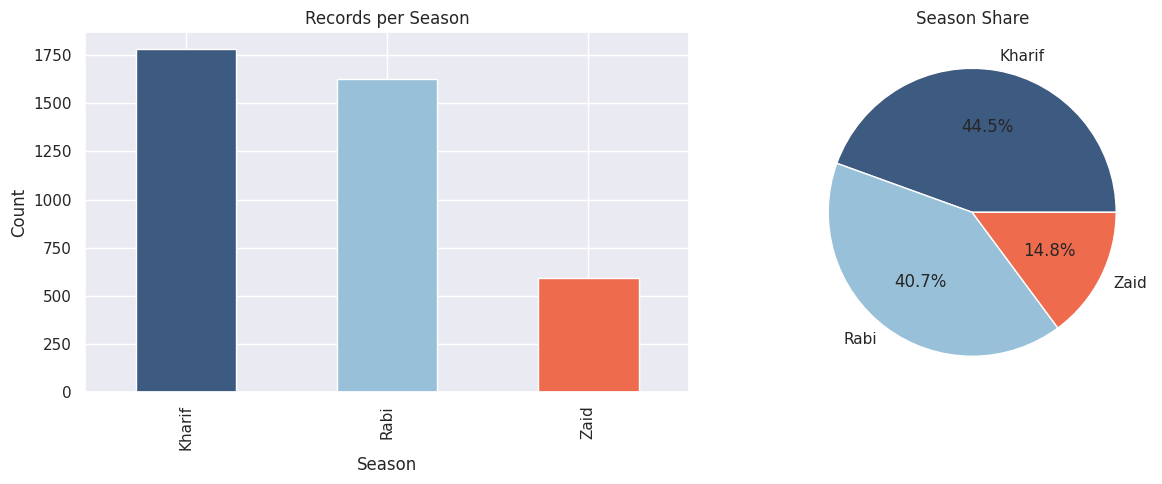

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
agri["Season"].value_counts().plot.bar(ax=axes[0], color=["#3d5a80", "#98c1d9", "#ee6c4d"])
axes[0].set_title("Records per Season")
axes[0].set_ylabel("Count")

agri["Season"].value_counts().plot.pie(autopct="%1.1f%%", ax=axes[1], colors=["#3d5a80", "#98c1d9", "#ee6c4d"])
axes[1].set_ylabel("")
axes[1].set_title("Season Share")
plt.tight_layout()
plt.show()

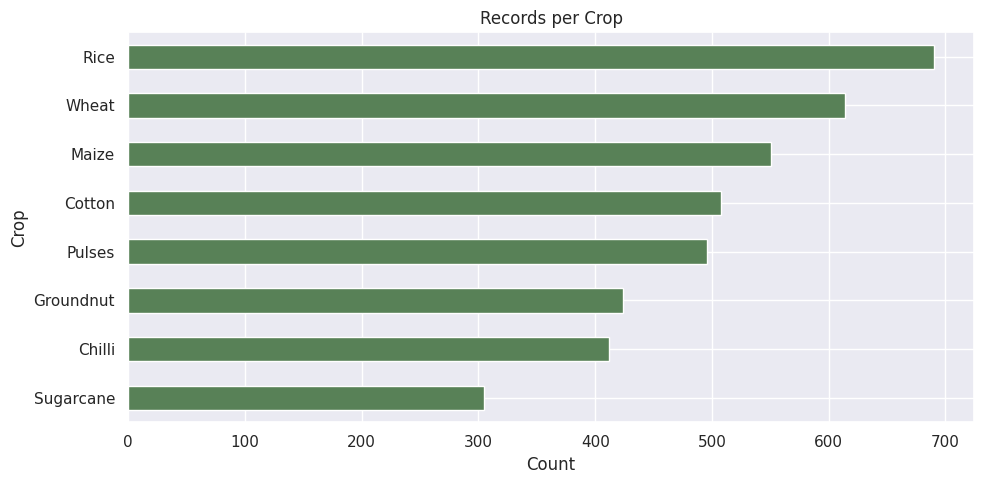

In [17]:
plt.figure(figsize=(10, 5))
agri["Crop"].value_counts().sort_values().plot.barh(color="#588157")
plt.title("Records per Crop")
plt.xlabel("Count")
plt.tight_layout()
plt.show()

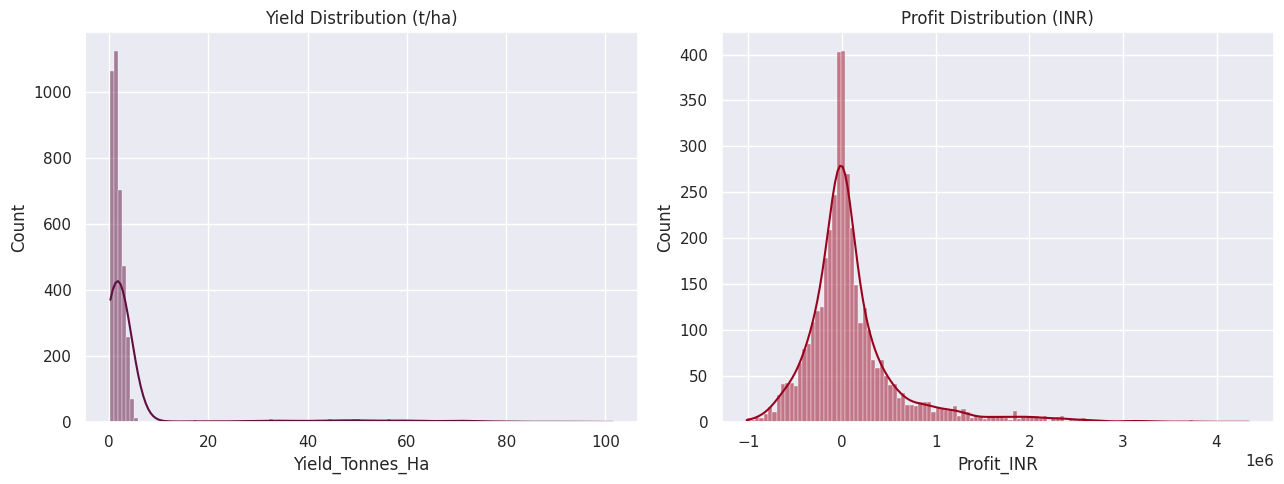

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
sns.histplot(agri["Yield_Tonnes_Ha"], kde=True, ax=axes[0], color="#5f0f40")
axes[0].set_title("Yield Distribution (t/ha)")

sns.histplot(agri["Profit_INR"], kde=True, ax=axes[1], color="#9a031e")
axes[1].set_title("Profit Distribution (INR)")
plt.tight_layout()
plt.show()

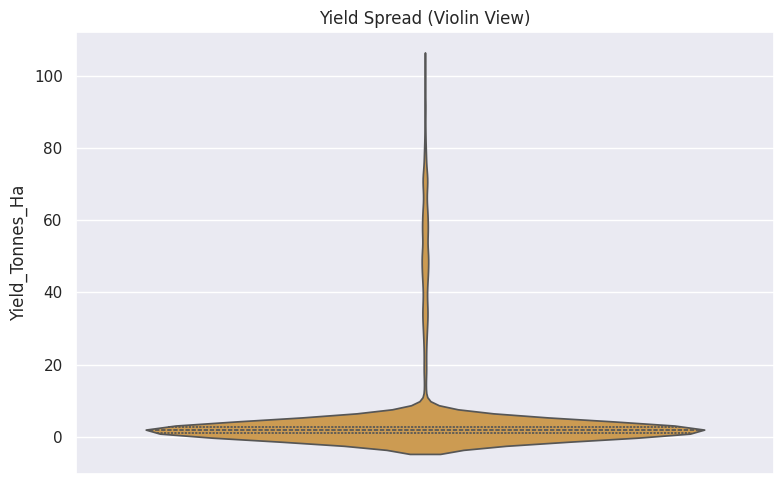

In [19]:
plt.figure(figsize=(8, 5))
sns.violinplot(y=agri["Yield_Tonnes_Ha"], color="#e09f3e", inner="quartile")
plt.title("Yield Spread (Violin View)")
plt.tight_layout()
plt.show()

## 8. Season as the Dividing Line

This is the heart of the brief: how does performance actually change from one season to the next?

/tmp/ipykernel_477/3678973324.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=agri, x="Season", y="Yield_Tonnes_Ha", ax=axes[0], palette="Set2")
/tmp/ipykernel_477/3678973324.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=agri, x="Season", y="Yield_Tonnes_Ha", ax=axes[1], errorbar="sd", palette="Set2")


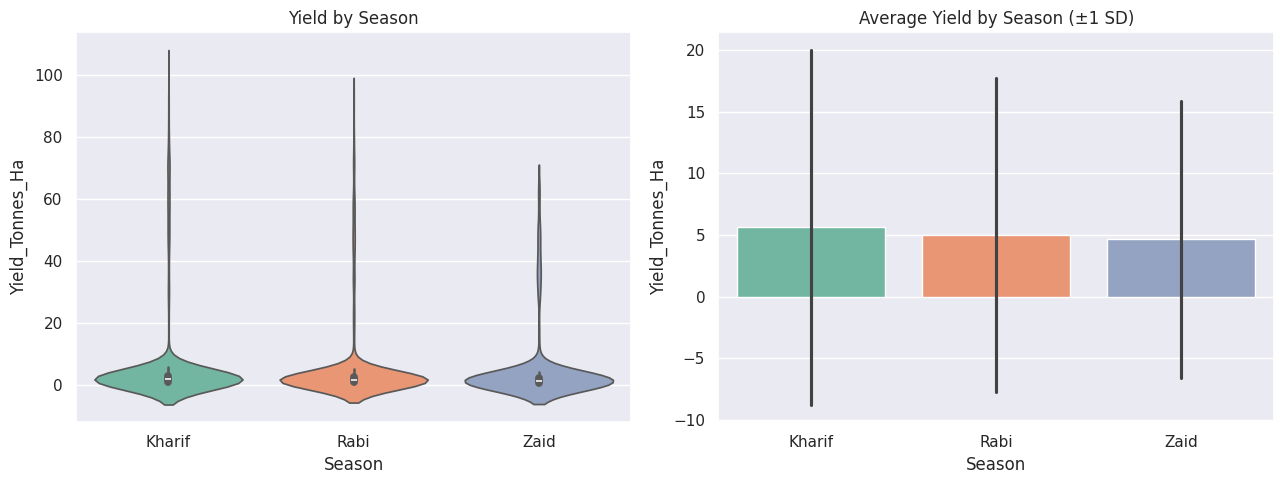

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
sns.violinplot(data=agri, x="Season", y="Yield_Tonnes_Ha", ax=axes[0], palette="Set2")
axes[0].set_title("Yield by Season")

sns.barplot(data=agri, x="Season", y="Yield_Tonnes_Ha", ax=axes[1], errorbar="sd", palette="Set2")
axes[1].set_title("Average Yield by Season (±1 SD)")
plt.tight_layout()
plt.show()

/tmp/ipykernel_477/1004886906.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=agri, x="Season", y="Profit_INR", ax=axes[0], palette="Set2")
/tmp/ipykernel_477/1004886906.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=agri, x="Season", y="Profit_INR", ax=axes[1], errorbar=None, palette="Set2")


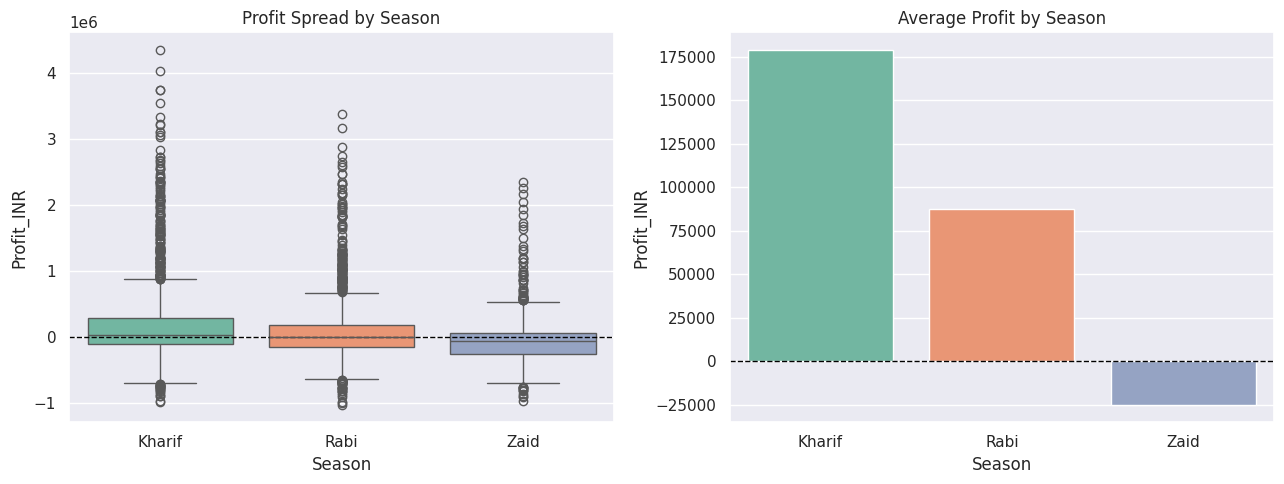

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
sns.boxplot(data=agri, x="Season", y="Profit_INR", ax=axes[0], palette="Set2")
axes[0].axhline(0, color="black", linewidth=1, linestyle="--")
axes[0].set_title("Profit Spread by Season")

sns.barplot(data=agri, x="Season", y="Profit_INR", ax=axes[1], errorbar=None, palette="Set2")
axes[1].axhline(0, color="black", linewidth=1, linestyle="--")
axes[1].set_title("Average Profit by Season")
plt.tight_layout()
plt.show()

/tmp/ipykernel_477/2438345295.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=agri, x="Season", y="Water_Used_m3", errorbar=None, palette="Set2")


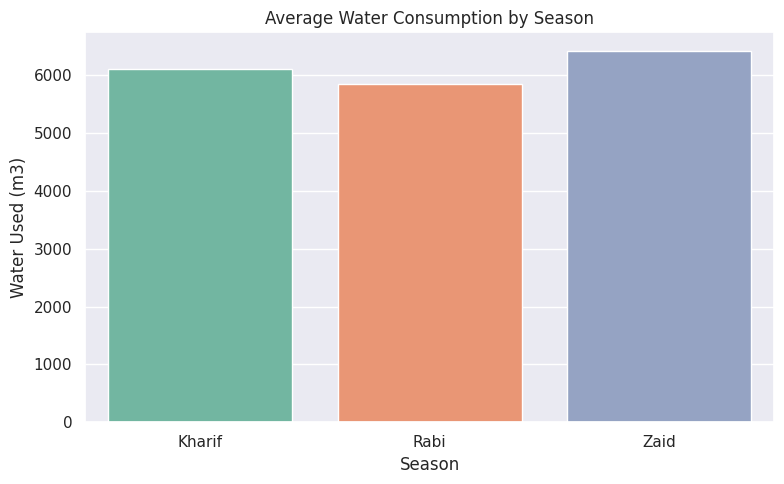

In [22]:
plt.figure(figsize=(8, 5))
sns.barplot(data=agri, x="Season", y="Water_Used_m3", errorbar=None, palette="Set2")
plt.title("Average Water Consumption by Season")
plt.ylabel("Water Used (m3)")
plt.tight_layout()
plt.show()

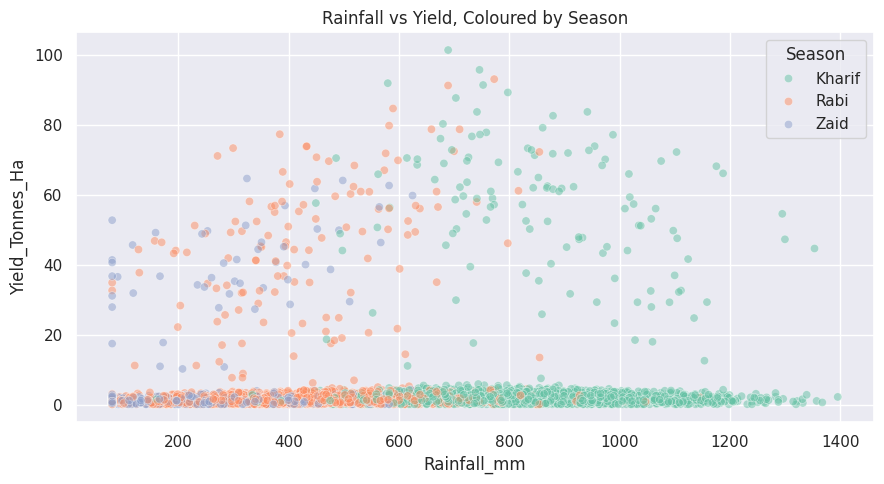

In [23]:
plt.figure(figsize=(9, 5))
sns.scatterplot(data=agri, x="Rainfall_mm", y="Yield_Tonnes_Ha", hue="Season", alpha=0.5, palette="Set2")
plt.title("Rainfall vs Yield, Coloured by Season")
plt.tight_layout()
plt.show()

/tmp/ipykernel_477/562302393.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=agri, x="Irrigation_Method", y="Yield_Tonnes_Ha", errorbar=None, palette="viridis")


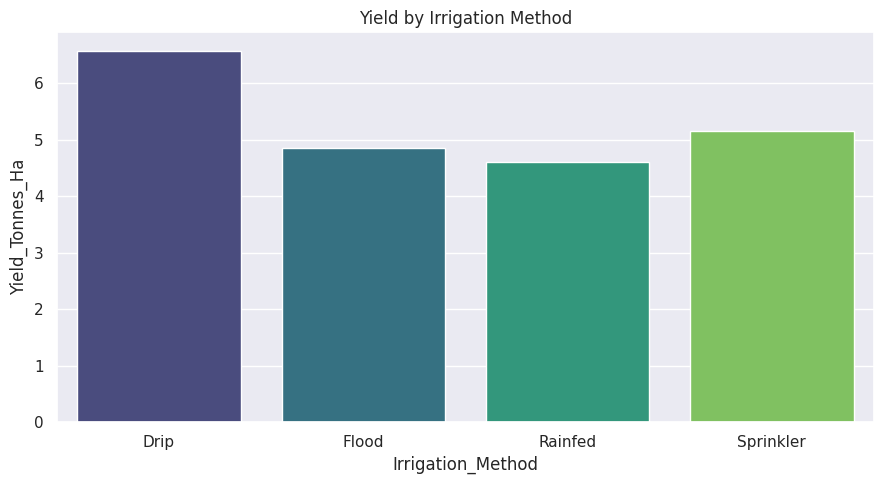

In [24]:
plt.figure(figsize=(9, 5))
sns.barplot(data=agri, x="Irrigation_Method", y="Yield_Tonnes_Ha", errorbar=None, palette="viridis")
plt.title("Yield by Irrigation Method")
plt.tight_layout()
plt.show()

## 9. Layering in a Third Variable

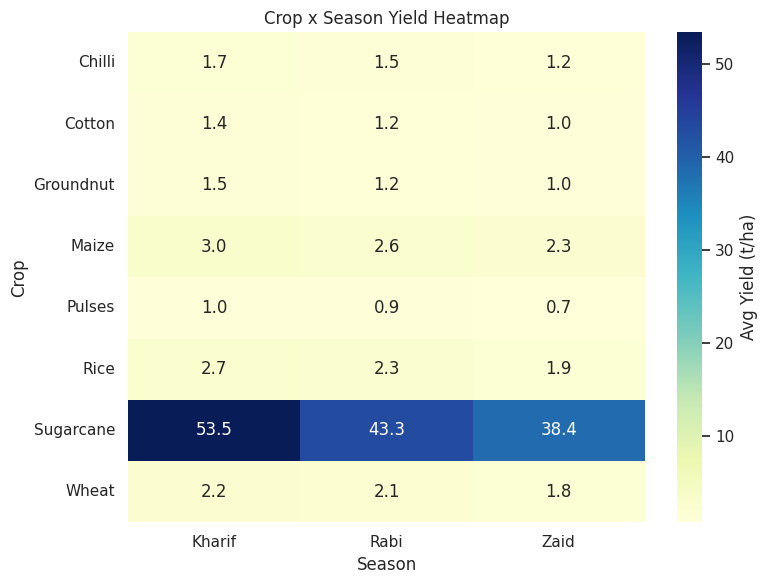

In [25]:
crop_season_pivot = agri.pivot_table(
    index="Crop", columns="Season", values="Yield_Tonnes_Ha", aggfunc="mean"
).round(2)

plt.figure(figsize=(8, 6))
sns.heatmap(crop_season_pivot, annot=True, fmt=".1f", cmap="YlGnBu", cbar_kws={"label": "Avg Yield (t/ha)"})
plt.title("Crop x Season Yield Heatmap")
plt.tight_layout()
plt.show()

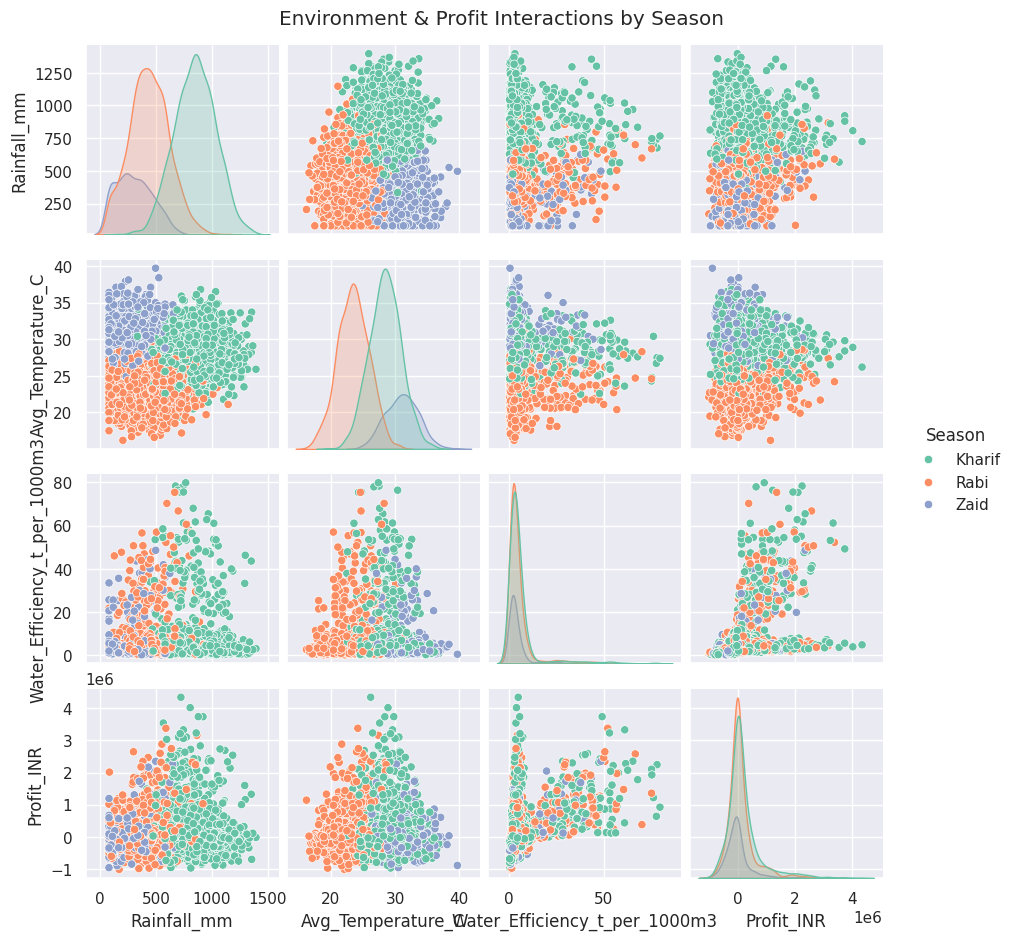

In [26]:
sample_cols = ["Rainfall_mm", "Avg_Temperature_C", "Water_Efficiency_t_per_1000m3", "Profit_INR"]
sns.pairplot(agri[sample_cols + ["Season"]], hue="Season", diag_kind="kde", palette="Set2", height=2.3)
plt.suptitle("Environment & Profit Interactions by Season", y=1.02)
plt.show()

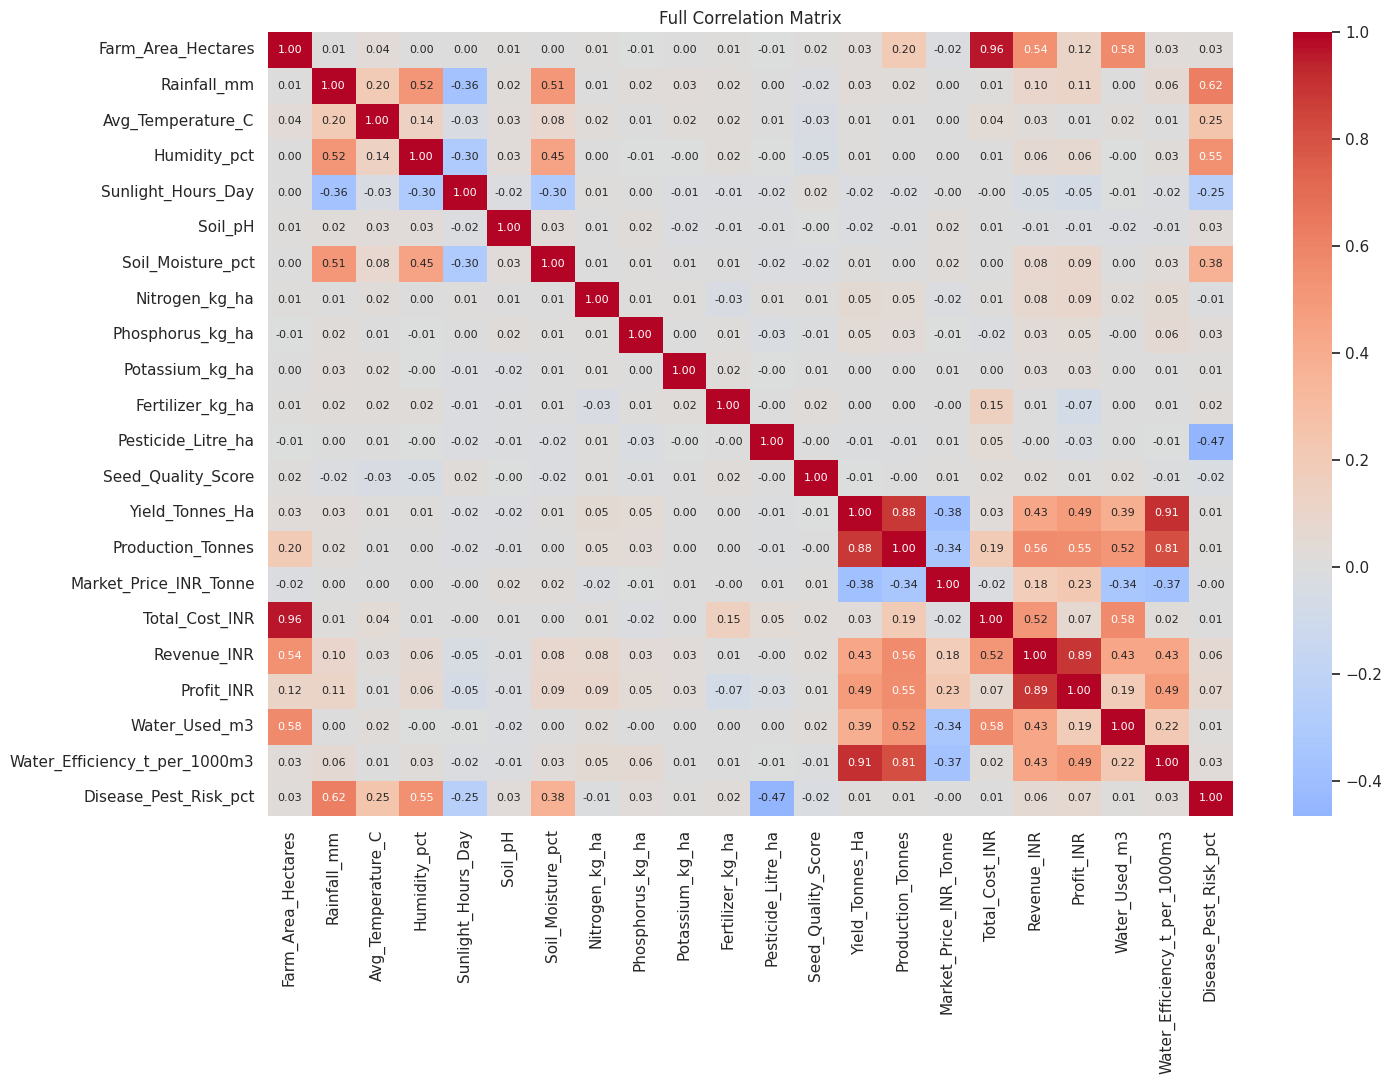

In [27]:
plt.figure(figsize=(15, 11))
corr_matrix = agri[numeric_features].corr(numeric_only=True)
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", center=0, annot_kws={"size": 8})
plt.title("Full Correlation Matrix")
plt.tight_layout()
plt.show()

## 10. Season Scorecard

In [28]:
season_scorecard = agri.groupby("Season").agg(
    Farms=("Farm_ID", "count"),
    Avg_Yield=("Yield_Tonnes_Ha", "mean"),
    Total_Production_T=("Production_Tonnes", "sum"),
    Avg_Profit=("Profit_INR", "mean"),
    Total_Profit=("Profit_INR", "sum"),
    Avg_Water_Used=("Water_Used_m3", "mean"),
    Avg_Disease_Risk=("Disease_Pest_Risk_pct", "mean"),
).round(2)

season_scorecard

,Farms,Avg_Yield,Total_Production_T,Avg_Profit,Total_Profit,Avg_Water_Used,Avg_Disease_Risk
Season,,,,,,,
Kharif,1779,5.63,"82,387.61","178,914.65",318289158,"6,102.20",54.47
Rabi,1627,5.04,"67,498.88","87,689.47",142670768,"5,846.99",40.48
Zaid,594,4.64,"23,098.35","-24,804.82",-14734066,"6,419.89",38.22


In [29]:
crop_by_season = agri.groupby(["Season", "Crop"]).agg(
    Avg_Yield=("Yield_Tonnes_Ha", "mean"),
    Avg_Profit=("Profit_INR", "mean"),
).round(2).sort_values(["Season", "Avg_Profit"], ascending=[True, False])

crop_by_season

Avg_Yield   Avg_Profit
Season Crop                             
Kharif Sugarcane      53.46 1,000,790.81
       Chilli          1.73   954,380.42
       Cotton          1.37   216,999.55
       Groundnut       1.48   108,265.44
       Pulses          1.04    43,338.90
       Maize           2.97   -39,332.67
       Rice            2.70   -64,903.40
       Wheat           2.25  -105,871.87
Rabi   Sugarcane      43.29   731,612.86
       Chilli          1.47   638,572.50
       Cotton          1.20   107,343.59
       Groundnut       1.23    10,416.54
       Pulses          0.88   -14,309.14
       Maize           2.60   -89,133.40
       Rice            2.32   -98,427.87
       Wheat           2.06  -119,954.57
Zaid   Sugarcane      38.42   583,635.80
       Chilli          1.20   448,659.09
       Cotton          0.96   -53,925.34
       Groundnut       1.04   -68,872.50
       Pulses          0.67  -139,227.81
       Wheat           1.75  -193,208.95
       Maize           2.29  -194,049.17
       Rice            1.90  -227,239.34

## 11. Three Questions I Wanted to Dig Into Myself

The sections above cover the standard seasonal breakdown. Here are three follow-up questions that came up while exploring the data, each chosen because it speaks directly to the planning-and-risk angle the brief asks about.

### 11.1 Which states hold their ranking across all three seasons — and which swing wildly?

*Why this matters: if a state's performance is unpredictable across seasons, seasonal advisories for it need to be far more cautious than for a state that behaves consistently.*

In [30]:
state_season_yield = agri.pivot_table(index="State", columns="Season", values="Yield_Tonnes_Ha", aggfunc="mean").round(2)
state_ranks = state_season_yield.rank(ascending=False, axis=0)

state_ranks["Rank_Spread"] = state_ranks.max(axis=1) - state_ranks.min(axis=1)
print("Average yield by state and season:")
print(state_season_yield)
print("\nRank spread (0 = perfectly consistent, higher = more volatile):")
print(state_ranks[["Rank_Spread"]].sort_values("Rank_Spread"))

Average yield by state and season:
Season          Kharif  Rabi  Zaid
State                             
Andhra Pradesh    5.68  3.47  4.45
Gujarat           6.34  5.44  4.07
Karnataka         6.46  4.57  6.62
Madhya Pradesh    5.99  3.76  5.48
Maharashtra       5.43  5.50  2.28
Punjab            4.10  8.61  5.91
Tamil Nadu        5.52  4.50  4.10
Telangana         5.55  4.78  4.25

Rank spread (0 = perfectly consistent, higher = more volatile):
Season          Rank_Spread
State                      
Tamil Nadu             0.00
Telangana              1.00
Andhra Pradesh         4.00
Karnataka              4.00
Madhya Pradesh         4.00
Gujarat                5.00
Maharashtra            6.00
Punjab                 7.00


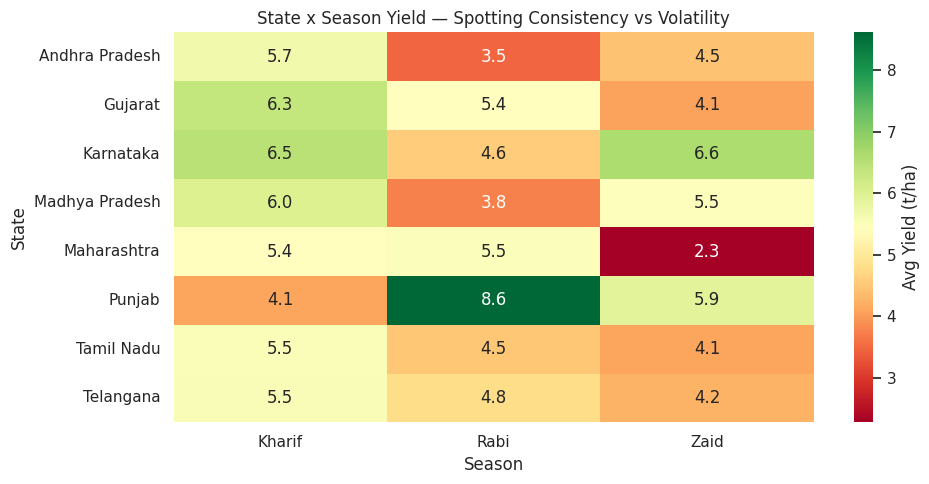

In [31]:
plt.figure(figsize=(10, 5))
sns.heatmap(state_season_yield, annot=True, fmt=".1f", cmap="RdYlGn", cbar_kws={"label": "Avg Yield (t/ha)"})
plt.title("State x Season Yield — Spotting Consistency vs Volatility")
plt.tight_layout()
plt.show()

### 11.2 Does farm size actually buy better performance?

*Why this matters: if profitability scales with farm size but yield efficiency does not, that's a meaningful equity signal — bigger farms may profit mainly through scale, not through being better managed per hectare.*

In [32]:
size_group = pd.qcut(agri["Farm_Area_Hectares"], 4, labels=["Small", "Medium", "Large", "Very Large"])
size_comparison = agri.groupby(size_group, observed=True).agg(
    Avg_Farm_Area=("Farm_Area_Hectares", "mean"),
    Avg_Yield_Per_Ha=("Yield_Tonnes_Ha", "mean"),
    Avg_Profit=("Profit_INR", "mean"),
).round(2)

size_comparison

,Avg_Farm_Area,Avg_Yield_Per_Ha,Avg_Profit
Farm_Area_Hectares,,,
Small,2.37,4.35,"27,648.84"
Medium,6.07,5.79,"80,164.23"
Large,9.80,5.32,"154,493.53"
Very Large,13.32,5.51,"184,030.86"


/tmp/ipykernel_477/4176260164.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=size_comparison.index, y=size_comparison["Avg_Yield_Per_Ha"], ax=axes[0], palette="crest")
/tmp/ipykernel_477/4176260164.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=size_comparison.index, y=size_comparison["Avg_Profit"], ax=axes[1], palette="crest")


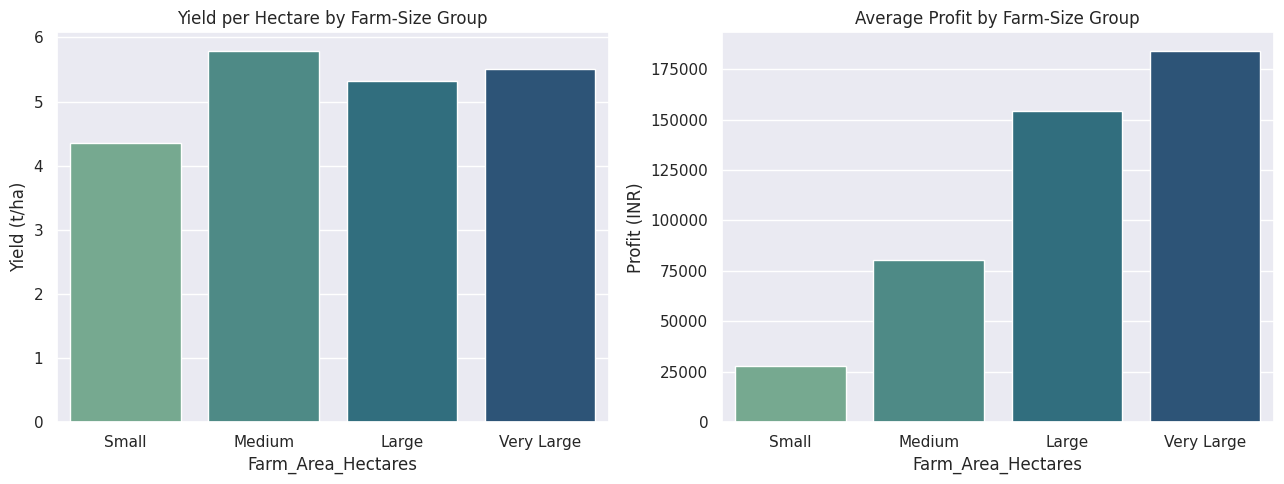

Correlation, Farm Area vs Yield: 0.03
Correlation, Farm Area vs Profit: 0.115


In [33]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
sns.barplot(x=size_comparison.index, y=size_comparison["Avg_Yield_Per_Ha"], ax=axes[0], palette="crest")
axes[0].set_title("Yield per Hectare by Farm-Size Group")
axes[0].set_ylabel("Yield (t/ha)")

sns.barplot(x=size_comparison.index, y=size_comparison["Avg_Profit"], ax=axes[1], palette="crest")
axes[1].set_title("Average Profit by Farm-Size Group")
axes[1].set_ylabel("Profit (INR)")
plt.tight_layout()
plt.show()

print("Correlation, Farm Area vs Yield:", round(agri["Farm_Area_Hectares"].corr(agri["Yield_Tonnes_Ha"]), 3))
print("Correlation, Farm Area vs Profit:", round(agri["Farm_Area_Hectares"].corr(agri["Profit_INR"]), 3))

### 11.3 Where does disease/pest risk concentrate by crop and season together?

*Why this matters: a single "average risk by season" number can hide that the danger is really concentrated in a handful of crop-season combinations, which is far more actionable for targeted monitoring.*

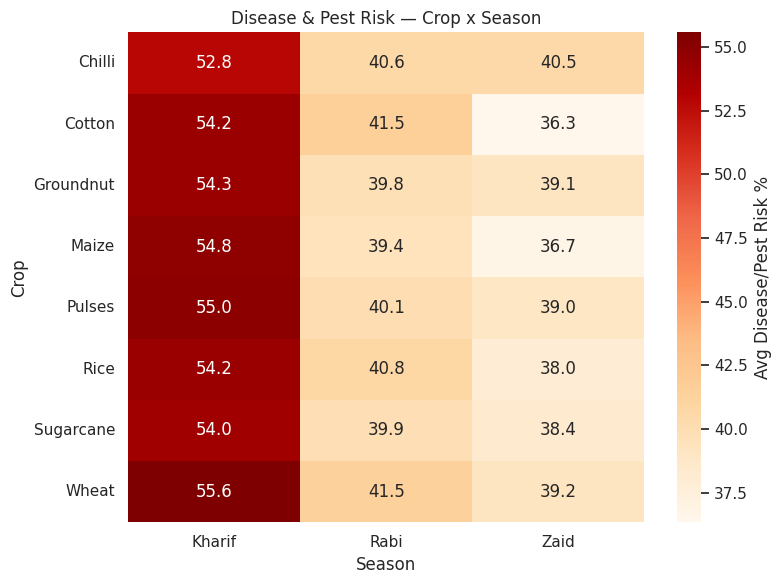

Riskiest combinations:
     Crop Season  Risk_Pct
    Wheat Kharif     55.58
   Pulses Kharif     54.96
    Maize Kharif     54.82
Groundnut Kharif     54.28
     Rice Kharif     54.25

Safest combinations:
     Crop Season  Risk_Pct
   Pulses   Zaid     38.97
Sugarcane   Zaid     38.35
     Rice   Zaid     37.95
    Maize   Zaid     36.68
   Cotton   Zaid     36.34


In [34]:
risk_matrix = agri.pivot_table(index="Crop", columns="Season", values="Disease_Pest_Risk_pct", aggfunc="mean").round(2)

plt.figure(figsize=(8, 6))
sns.heatmap(risk_matrix, annot=True, fmt=".1f", cmap="OrRd", cbar_kws={"label": "Avg Disease/Pest Risk %"})
plt.title("Disease & Pest Risk — Crop x Season")
plt.tight_layout()
plt.show()

flat_risk = risk_matrix.stack().rename("Risk_Pct").reset_index().sort_values("Risk_Pct", ascending=False)
print("Riskiest combinations:")
print(flat_risk.head(5).to_string(index=False))
print("\nSafest combinations:")
print(flat_risk.tail(5).to_string(index=False))

## 12. What the Evidence Shows

Each point below is stated as: what I saw → what supports it → what it likely means → what it does *not* prove.

1. **Kharif outperforms Rabi, which outperforms Zaid, on both yield and profit.** (Section 10 scorecard) — Kharif averages 5.63 t/ha and a positive total profit; Zaid averages 4.64 t/ha and is the only season with a net loss overall. This is an association between season and outcome; the scorecard doesn't isolate *why* Zaid lags (heat stress, water stress, or something else could all fit).

2. **Financial risk is not evenly spread — it climbs sharply toward Zaid.** Roughly 42% of Kharif farms show a loss versus around 64% of Zaid farms (computed from `Profit_INR < 0`, grouped by season). This is a stronger planning signal than the average profit figure alone, since averages can mask how many individual farms are struggling.

3. **Water efficiency tracks yield far more tightly than rainfall volume or fertilizer dose.** The correlation heatmap (Section 9) shows `Water_Efficiency_t_per_1000m3` correlated with yield at roughly r=0.91, while rainfall and fertilizer sit near r=0.03–0.06. Note that water efficiency is calculated *from* yield, so part of this relationship is close to circular by construction — it shouldn't be read as an independent causal driver.

4. **Tamil Nadu is the most seasonally consistent state; Punjab is the most volatile.** In the rank-spread check (Section 11.1), Tamil Nadu holds the *same* relative rank (6th) in Kharif, Rabi and Zaid alike. Punjab swings from 1st in Rabi to last (8th) in Kharif. This says a single seasonal calendar can't apply equally to every state.

5. **Bigger farms show higher average profit, but not proportionally higher yield per hectare.** Very Large farms report roughly 6-7x the average profit of Small farms, yet yield per hectare is fairly flat across size groups (Section 11.2). This points to profit scaling mostly with land area rather than farms getting more efficient as they grow.

6. **Disease/pest risk is concentrated in Kharif, and worst for Wheat.** The crop-season risk heatmap (Section 11.3) shows Wheat-in-Kharif as the single riskiest combination (~55.6%), while Pulses-in-Zaid is the safest (~39%). This is an exposure score from the dataset, not a confirmed record of crop loss.

7. **Market price barely moves profit; yield does the heavier lifting.** `Market_Price_INR_Tonne` correlates with `Profit_INR` at only around r=0.23, well below yield's contribution. Treating "get a better price" as the main lever for profitability isn't well supported by this dataset.

8. **Drip irrigation combines competitive yield with above-average water efficiency**, while Flood irrigation uses the most water for a comparatively lower yield (Section 8 irrigation chart). Irrigation choice, however, is not randomly assigned in this data, so farm investment level or crop choice could be confounded with the irrigation method itself.

9. **Sugarcane's yield numbers are on a completely different scale (38-53 t/ha) than every other crop** (Section 12 heatmap), which means any *pooled* "average yield" statistic quoted without separating crops can be misleading.

## 13. What the Data Supports Doing Next

- **Target Zaid-season farmers for support first.** With the highest share of loss-making farms and the only season in net loss, this is where intervention (credit access, water-saving measures, agronomic advice) would address the most acute need. *Caveat: the dataset doesn't say what specifically drives Zaid's underperformance, so a diagnostic step should come before any fixed program.*

- **Build state-specific seasonal calendars instead of one national one.** Because Punjab and Tamil Nadu behave so differently across seasons (Section 11.1), a single "best season" recommendation will be wrong for at least some states. *Caveat: this analysis is at state level; some states may hide district-level variation that a single number can't capture.*

- **Time disease/pest monitoring budgets around Kharif, and around Wheat specifically.** The risk heatmap makes a clear case for where monitoring resources would catch the most exposure. *Caveat: risk score ≠ confirmed loss, so this should be paired with tracking actual crop damage to validate the investment.*

- **Investigate drip-irrigation expansion where feasible**, since it shows the best yield-to-water tradeoff of the four methods in this dataset. *Caveat: switching irrigation methods involves upfront cost and infrastructure that this dataset doesn't capture — a pilot comparison would be needed before scaling up.*

- **Be cautious about farm-size-driven growth strategies.** Since yield per hectare doesn't rise meaningfully with farm size, encouraging land consolidation purely to raise profit may work through scale rather than genuine productivity gains. *Caveat: only farm area is measured here; capital, labor and technology differences by farm size aren't captured.*

- **Avoid blending Sugarcane with other crops in any "average yield" reporting.** Given the scale mismatch, Sugarcane should be reported separately to avoid distorting headline figures used for planning.

## 14. Closing Summary

This analysis set out to answer four questions: does season change performance, what factors move with it, how consistent are these patterns regionally, and where does risk concentrate.

The data gives a fairly clear answer to the first: **yes** — Kharif is consistently the strongest season, Zaid the weakest, and this pattern holds up across crops, states, and multiple performance measures (yield, profit, and loss-making share).

On the second question, **water efficiency stands out far more than rainfall or fertilizer dose** as the variable most tightly linked to yield, though this needs to be read carefully given how the metric is calculated.

On the third, the answer is **not very consistent** — states like Punjab and Tamil Nadu behave in almost opposite ways across seasons, which argues against a single blanket seasonal strategy.

On the fourth, **risk is not evenly distributed**: it's concentrated in the Zaid season financially, and in Kharif-grown Wheat agronomically.

**Limitations worth remembering:** this is a single cross-sectional snapshot rather than a multi-year time series, so none of the patterns above can be treated as proven causes — they are associations worth investigating further. Several derived metrics (like water efficiency) are mathematically linked to the outcome variable, which can inflate how strong a relationship looks.

**Where this could go next:** a multi-year version of this dataset would let us test whether these seasonal patterns are stable trends or one-off conditions, and a deeper look at *why* Zaid underperforms would turn this from a descriptive study into something closer to a diagnostic one.